In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

In [2]:
rf_df = pd.read_csv('../data/refactored_df.csv')
fs_df = pd.read_csv('../data/Final Sales.csv')

rf_df['Date'] = pd.to_datetime(rf_df['Date'])
fs_df['Date'] = pd.to_datetime(fs_df['Date'])

rf_df = rf_df[rf_df['Date'] < '2024-04-01']
fs_df = fs_df[fs_df['Date'] >= '2024-04-01']

rf_df.drop(columns=['Year', 'Month', 'Week'], inplace=True)
rf_df['Segment'] = rf_df['Segment'].replace('Inverter', 'Inv')

fs_df.drop(columns=['Inv. No.', 'Item Code', 'Status', 'State'], inplace=True)
fs_df['Technology'] = fs_df['Technology'].replace('H&C Inv', 'Inv')
fs_df.rename(columns={'Sales Qty.': 'Qty', 'Technology': 'Segment'}, inplace=True)

rf_df.rename(columns={'Rating': 'Star rating'}, inplace=True)

rf_df['Branch'].replace('SBD1', 'VJW', inplace=True)

fs_df['Branch'].replace('HYDERABAD', 'SBD', inplace=True)
fs_df['Branch'].replace('CHENNAI', 'MAA', inplace=True)
fs_df['Branch'].replace('BANGALORE', 'BLR', inplace=True)
fs_df['Branch'].replace('VIJAYWADA', 'VJW', inplace=True)
fs_df['Branch'].replace('VIJAYAWADA', 'VJW', inplace=True)
fs_df['Branch'].replace('COCHIN', 'COK', inplace=True)

C:\Users\sahil\AppData\Local\Temp\ipykernel_18172\844445293.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  fs_df = pd.read_csv('../data/Final Sales.csv')
C:\Users\sahil\AppData\Local\Temp\ipykernel_18172\844445293.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rf_df['Branch'].replace('SBD1', 'VJW', inplace=True)
C:\Users\sahil\AppData\Local\Temp\ipykernel_18172\844445293.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series throug

In [3]:
final_df=pd.concat([rf_df, fs_df], ignore_index=True).reset_index(drop=True)

In [4]:
# Fill missing data for 2020-04 using average of 2020-03 and 2020-05 for each branch

# Step 1: Detect missing 2020-04 for each branch
branches = final_df['Branch'].unique()
missing_apr = []
for branch in branches:
    mask_apr = (final_df['Date'] >= '2020-04-01') & (final_df['Date'] <= '2020-04-30') & (final_df['Branch'] == branch)
    if final_df.loc[mask_apr].empty:
        missing_apr.append(branch)

# Step 2: For each branch missing 2020-04, compute average of Mar and May
for branch in missing_apr:
    mar_mask = (final_df['Date'] >= '2020-03-01') & (final_df['Date'] <= '2020-03-31') & (final_df['Branch'] == branch)
    may_mask = (final_df['Date'] >= '2020-05-01') & (final_df['Date'] <= '2020-05-31') & (final_df['Branch'] == branch)
    mar_df = final_df.loc[mar_mask].copy()
    may_df = final_df.loc[may_mask].copy()
    if mar_df.empty or may_df.empty:
        # If either Mar or May is missing for this branch, skip
        continue
    # For each day in April, interpolate between Mar 31 and May 1,
    # If those days don't exist, take mean of whole month Mar and May
    mar_qty = mar_df['Qty'].mean()
    may_qty = may_df['Qty'].mean()
    avg_apr_qty = round((mar_qty + may_qty) / 2)
    # Add one row for each day in April as the average (or just the month sum for April)
    april_dates = pd.date_range('2020-04-01', '2020-04-30', freq='D')
    # If in the original data, there is varying number of entries per day or per month, keep same granularity - here, we fill with daily rows
    new_rows = []
    for dt in april_dates:
        new_rows.append({
            'Date': dt,
            'Branch': branch,
            'Qty': avg_apr_qty,
        })
    new_rows_df = pd.DataFrame(new_rows)
    # Fill remaining columns with values from March if possible, else May, else leave NaN
    ref_row = mar_df.iloc[0] if not mar_df.empty else (may_df.iloc[0] if not may_df.empty else None)
    if ref_row is not None:
        for col in final_df.columns:
            if col in ['Date', 'Branch', 'Qty']:
                continue
            new_rows_df[col] = ref_row[col]
    # Append
    final_df = pd.concat([final_df, new_rows_df], ignore_index=True)

# After filling, sort to keep order
final_df = final_df.sort_values(['Date', 'Branch']).reset_index(drop=True)


In [11]:
final_df['Month'] = final_df['Date'].dt.to_period('M').dt.to_timestamp()
monthly_qty = final_df.groupby('Month', as_index=False)['Qty'].sum()
monthly_qty_branch = final_df.groupby(['Month', 'Branch'], as_index=False)['Qty'].sum()

In [13]:
monthly_qty_branch.to_csv('../data/monthly_qty_branch.csv', index=False)

In [10]:
monthly_qty.to_csv('../data/monthly_qty.csv', index=False)

In [17]:
qty_daily = final_df.groupby(['Date', 'Branch'])['Qty'].sum().reset_index()

In [18]:
import plotly.express as px

# Prepare data for plotting
fig = px.line(qty_daily, x='Date', y='Qty', color='Branch',
              title='Branch-wise Qty Sales Over Time',
              labels={'Qty': 'Sales Qty', 'Date': 'Date', 'Branch': 'Branch'})

fig.update_layout(legend_title_text='Branch', width=700, height=400)
fig.show()


In [19]:
qty_daily.to_csv('../data/qty_daily.csv', index=False)

In [20]:
qty_daily_company = qty_daily.groupby(['Date'])['Qty'].sum().reset_index()
qty_daily_company.to_csv('../data/qty_daily_company.csv', index=False)


In [5]:
# Example assumes your 'Date' column is datetime
final_df['Year'] = final_df['Date'].dt.year
final_df['Month'] = final_df['Date'].dt.month
final_df['Week'] = final_df['Date'].dt.isocalendar().week  # replaces deprecated .dt.week
final_df['Branch'].replace('VIJAYAWADA', 'VJW', inplace=True)
# Financial Year (April–March)
final_df['F_Year'] = final_df['Date'].apply(
    lambda x: x.year if x.month >= 4 else x.year - 1
)

# Financial Month: April as month 1, March as month 12
final_df['F_Month'] = final_df['Date'].apply(
    lambda x: x.month - 3 if x.month >= 4 else x.month + 9
)

# Optional: Create a human-readable Financial Year label like '2024-25'
final_df['F_Year_Label'] = final_df['F_Year'].astype(str) + '-' + (final_df['F_Year'] + 1).astype(str).str[-2:]

# Set region
final_df['Region'] = 'South'


C:\Users\sahil\AppData\Local\Temp\ipykernel_18320\79841839.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['Branch'].replace('VIJAYAWADA', 'VJW', inplace=True)


In [91]:
final_df.to_csv('../data/final_df.csv', index=False)

In [6]:
# Create a YearMonth column as YYYY-MM-01 (first of month)
final_df['YearMonth'] = final_df['Date'].dt.to_period('M').dt.to_timestamp()

# Group by YearMonth and Branch, and sum the Qty
qty_grouped = final_df.groupby(['YearMonth', 'Branch'])['Qty'].sum().reset_index()
qty_grouped['YearMonth'] = qty_grouped['YearMonth'].astype(str)
branches = qty_grouped['Branch'].unique()
to_rows = []
for branch in branches:
    march = qty_grouped[(qty_grouped['YearMonth'] == '2020-03-01') & (qty_grouped['Branch'] == branch)]
    may = qty_grouped[(qty_grouped['YearMonth'] == '2020-05-01') & (qty_grouped['Branch'] == branch)]
    april_exists = ((qty_grouped['YearMonth'] == '2020-04-01') & (qty_grouped['Branch'] == branch)).any()
    if not april_exists:
        qty_march = march['Qty'].values[0] if not march.empty else np.nan
        qty_may = may['Qty'].values[0] if not may.empty else np.nan
        # Only compute if at least one month is available
        if not np.isnan(qty_march) or not np.isnan(qty_may):
            average_qty = np.nanmean([qty_march, qty_may])
            to_rows.append({'YearMonth': '2020-04-01', 'Branch': branch, 'Qty': average_qty})

# Append the new rows
if to_rows:
    qty_grouped = pd.concat([qty_grouped, pd.DataFrame(to_rows)])
    # Sort for tidy output
    qty_grouped = qty_grouped.sort_values(by=['YearMonth', 'Branch']).reset_index(drop=True)

# Show the fixed dataframe
qty_grouped.rename(columns={'YearMonth': 'Date'}, inplace=True)
qty_grouped['Date'] = pd.to_datetime(qty_grouped['Date'])


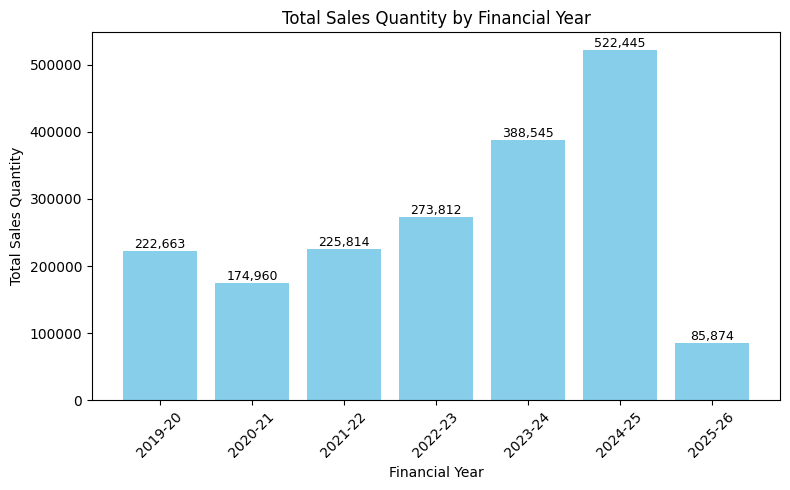

In [7]:
import matplotlib.pyplot as plt

# Calculate total sales per financial year
fy_totals = final_df.groupby('F_Year')['Qty'].sum().reset_index()

# Create a human-readable label for each financial year, e.g. '2024-25'
fy_totals['F_Year_Label'] = fy_totals['F_Year'].astype(str) + '-' + (fy_totals['F_Year'] + 1).astype(str).str[-2:]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(fy_totals['F_Year_Label'], fy_totals['Qty'], color='skyblue')
plt.xlabel('Financial Year')
plt.ylabel('Total Sales Quantity')
plt.title('Total Sales Quantity by Financial Year')
plt.xticks(rotation=45)
# Annotate bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():,.0f}", 
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


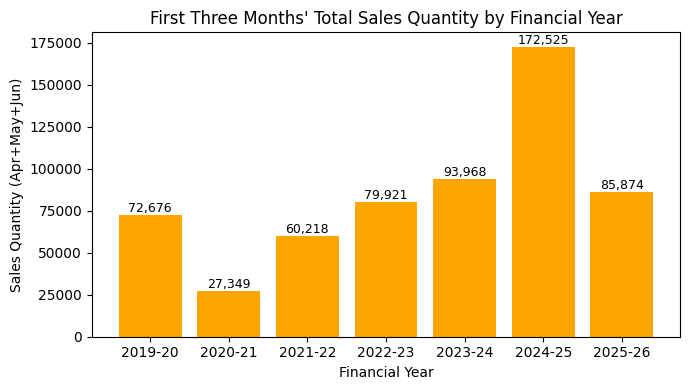

In [8]:
# Calculate the sum of sales for first 3 months of each financial year
# (Assume financial year runs from April to March, so April=4, May=5, June=6 in the F_Year start)
first_three_months = final_df[final_df['Month'].isin([4, 5, 6])]

# Sum quantity per financial year for first three months
fy_first3 = first_three_months.groupby('F_Year')['Qty'].sum().reset_index()
fy_first3['F_Year_Label'] = fy_first3['F_Year'].astype(str) + '-' + (fy_first3['F_Year'] + 1).astype(str).str[-2:]

plt.figure(figsize=(7, 4))
bars = plt.bar(fy_first3['F_Year_Label'], fy_first3['Qty'], color='orange')
plt.title("First Three Months' Total Sales Quantity by Financial Year")
plt.xlabel('Financial Year')
plt.ylabel('Sales Quantity (Apr+May+Jun)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{bar.get_height():,.0f}", 
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


In [95]:
import plotly.express as px

# Ensure YearMonth is string for axis labeling
qty_grouped['Date'] = qty_grouped['Date'].astype(str)

fig = px.line(
    qty_grouped, 
    x='Date', 
    y='Qty', 
    color='Branch',
    title='Monthly Sales Quantity for Each Branch',
    labels={'YearMonth': 'Year-Month', 'Qty': 'Total Quantity', 'Branch': 'Branch'},
    markers=True
)
fig.update_layout(
    xaxis=dict(tickangle=45),
    legend_title_text='Branch',
    hovermode='x unified'
)
fig.show()


In [96]:
import pandas as pd

# Ensure Year and Month columns are present
qty_grouped['Year'] = qty_grouped['Date'].str[:4].astype(int)
qty_grouped['Month'] = qty_grouped['Date'].str[5:7].astype(int)

# Group by Branch and Month, then calculate average quantity for each month over all available years (for each branch)
monthly_branch_avg = qty_grouped.groupby(['Branch', 'Month'])['Qty'].mean().reset_index()

# Convert month number to month name for nicer plotting (optional)
import calendar
monthly_branch_avg['MonthName'] = monthly_branch_avg['Month'].apply(lambda x: calendar.month_abbr[x])

import plotly.express as px
fig = px.line(
    monthly_branch_avg,
    x='MonthName',
    y='Qty',
    color='Branch',
    markers=True,
    labels={'MonthName': 'Month', 'Qty': 'Average Quantity', 'Branch': 'Branch'},
    title='Average Monthly Sales for Each Branch'
)
fig.update_xaxes(categoryorder='array', categoryarray=[calendar.month_abbr[m] for m in range(1,13)])
fig.show()



In [97]:
# Calculate the cumulative average sales across each month (for each branch)
# Approach: For each branch, compute the expanding mean up to each month (across months in order, for all years combined)

# First, sort the qty_grouped data by Branch and YearMonth for correct order
qty_grouped_sorted = qty_grouped.sort_values(['Branch', 'Year', 'Month'])

# Group by Branch and compute cumulative sum/mean of Qty
qty_grouped_sorted['CumulativeAvgQty'] = qty_grouped_sorted.groupby('Branch')['Qty'].expanding().mean().reset_index(level=0, drop=True)

# Create Month name for plotting
qty_grouped_sorted['MonthName'] = qty_grouped_sorted['Month'].apply(lambda x: calendar.month_abbr[x])

# Optional: You may want to display only the final cumulative average per month, averaged over all years
# So, group again by Branch and Month to get the last cumulative avg in that month for each (across years)

cumul_avg_by_month = qty_grouped_sorted.groupby(['Branch', 'Month']).agg({
    'CumulativeAvgQty': 'last'
}).reset_index()
cumul_avg_by_month['MonthName'] = cumul_avg_by_month['Month'].apply(lambda x: calendar.month_abbr[x])

fig = px.line(
    cumul_avg_by_month, 
    x='MonthName', 
    y='CumulativeAvgQty', 
    color='Branch',
    markers=True,
    labels={'MonthName': 'Month', 'CumulativeAvgQty': 'Cumulative Avg Qty', 'Branch': 'Branch'},
    title='Cumulative Average Sales Across Each Month for Each Branch'
)
fig.update_xaxes(categoryorder='array', categoryarray=[calendar.month_abbr[m] for m in range(1,13)])
fig.show()


In [98]:

# Calculate the cumulative average sales across each month (ignoring branches)

# Sort qty_grouped by Year and Month
qty_grouped_sorted = qty_grouped.sort_values(['Year', 'Month'])

# Compute running/expanding mean of Qty across all months
qty_grouped_sorted['CumulativeAvgQty'] = qty_grouped_sorted['Qty'].expanding().mean()

# Convert month number to month name
qty_grouped_sorted['MonthName'] = qty_grouped_sorted['Month'].apply(lambda x: calendar.month_abbr[x])

# For visualization, plot cumulative average for each calendar month (using the last available for that month)
cumul_avg_by_month = qty_grouped_sorted.groupby('Month').agg({'CumulativeAvgQty': 'last'}).reset_index()
cumul_avg_by_month['MonthName'] = cumul_avg_by_month['Month'].apply(lambda x: calendar.month_abbr[x])

fig = px.line(
    cumul_avg_by_month,
    x='MonthName',
    y='CumulativeAvgQty',
    markers=True,
    labels={'MonthName': 'Month', 'CumulativeAvgQty': 'Cumulative Avg Qty'},
    title='Cumulative Average Sales Across Each Month (All Branches)'
)
fig.update_xaxes(categoryorder='array', categoryarray=[calendar.month_abbr[m] for m in range(1,13)])
fig.show()




In [104]:
def create_ml_features(branch_df, anchor_month=4, season_years_back=2, lags=[1, 2, 3, 6, 12], rolling_windows=[3, 6, 12]):
    df = branch_df.copy()
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

    df['Is_FY_Start'] = (df['Month'] == 4).astype(int)
    df['Is_FY_End'] = (df['Month'] == 3).astype(int)

    df['FinancialYear'] = df.apply(
        lambda r: r['Year'] if r['Month'] >= 4 else r['Year'] - 1, axis=1)

    fy_monthly = df.groupby(['FinancialYear', 'Month'])[
        'Qty'].sum().reset_index(name='FYMonthTotal')

    fy_list = sorted(df['FinancialYear'].unique())
    si_records = []
    for fy in fy_list:
        season_fys = [fy - i for i in range(season_years_back, 0, -1)]
        if all(season_fys[si] in fy_monthly['FinancialYear'].unique() for si in range(season_years_back)):
            season_data = fy_monthly[fy_monthly['FinancialYear'].isin(
                season_fys)]
            month_means = season_data.groupby(
                'Month')['FYMonthTotal'].mean().reset_index()
            march_row = month_means[month_means['Month'] == anchor_month]
            if not march_row.empty and march_row['FYMonthTotal'].iloc[0] != 0:
                anchor_val = march_row['FYMonthTotal'].iloc[0]
            else:
                anchor_val = 1.0
            month_means['SeasonalIndex'] = month_means['FYMonthTotal'] / anchor_val
            month_means['FinancialYear'] = fy
            si_records.append(month_means[['FinancialYear', 'Month', 'SeasonalIndex']])
    si_all = pd.concat(si_records) if si_records else pd.DataFrame(columns=['FinancialYear', 'Month', 'SeasonalIndex'])
    df = df.merge(si_all, on=['FinancialYear', 'Month'], how='left')
    # ============== Advanced FE ==============
    df = df.sort_values('Date')

    # Lag features (more comprehensive set)
    for lag in lags:
        df[f'Qty_lag_{lag}'] = df['Qty'].shift(lag)

    # Additional specific lags
    for lag in [1, 2, 3, 6, 12, 24]:
        if lag not in lags:
            df[f'Qty_lag_{lag}'] = df['Qty'].shift(lag)

    # Delta features (differences)
    for lag in [1, 2, 3, 6, 12]:
        df[f'Qty_delta_{lag}'] = df['Qty'] - df['Qty'].shift(lag)

    # Percentage change features
    for lag in [1, 2, 3, 6, 12]:
        df[f'Qty_pct_change_{lag}'] = df['Qty'].pct_change(lag)

    # Rolling window features (more comprehensive)
    for window in rolling_windows:
        df[f'Qty_roll_mean_{window}'] = df['Qty'].rolling(window=window, min_periods=1).mean()
        df[f'Qty_roll_std_{window}'] = df['Qty'].rolling(window=window, min_periods=1).std()
        df[f'Qty_roll_min_{window}'] = df['Qty'].rolling(window=window, min_periods=1).min()
        df[f'Qty_roll_max_{window}'] = df['Qty'].rolling(window=window, min_periods=1).max()
        df[f'Qty_roll_median_{window}'] = df['Qty'].rolling(window=window, min_periods=1).median()

    # Additional rolling windows
    for window in [3, 6, 12, 24]:
        if window not in rolling_windows:
            df[f'Qty_roll_mean_{window}'] = df['Qty'].rolling(window=window, min_periods=1).mean()
            df[f'Qty_roll_std_{window}'] = df['Qty'].rolling(window=window, min_periods=1).std()

    # Exponential weighted moving averages
    for alpha in [0.1, 0.3, 0.5]:
        df[f'Qty_ewm_{alpha}'] = df['Qty'].ewm(alpha=alpha, adjust=False).mean()

    # Year-to-date features
    df['Qty_ytd_sum'] = df.groupby(df['Date'].dt.to_period('Y'))['Qty'].cumsum()
    df['Qty_ytd_mean'] = df.groupby(df['Date'].dt.to_period('Y'))['Qty'].transform(lambda x: x.expanding().mean())

    # Financial year features
    fy_groups = df.groupby('FinancialYear')['Qty']
    df['Qty_fy_cumsum'] = fy_groups.cumsum()
    df['Qty_fy_cummean'] = fy_groups.transform(lambda x: x.expanding().mean())

    # Month-over-month growth rate
    df['Qty_mom_growth'] = df['Qty'].pct_change(1)
    df['Qty_yoy_growth'] = df['Qty'].pct_change(12)  # Year-over-year

    # Trend features (slope over windows)
    for window in [3, 6, 12]:
        df[f'Qty_trend_{window}'] = df['Qty'].rolling(window=window).apply(
            lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) == window else np.nan, raw=False
        )

    # ============== End Advanced FE ===========
    df.drop(['Branch'], axis=1, inplace=True)
    df.dropna(inplace=True)
    return df

In [107]:
qty_grouped['Date'] = pd.to_datetime(qty_grouped['Date'])

for i in [1,2,3]:
    for branch in qty_grouped['Branch'].unique():
        feature_blr = create_ml_features(branch_df=qty_grouped[qty_grouped['Branch'] == 'BLR'], season_years_back=i)
        feature_maa = create_ml_features(branch_df=qty_grouped[qty_grouped['Branch'] == 'MAA'], season_years_back=i)
        feature_vjw = create_ml_features(branch_df=qty_grouped[qty_grouped['Branch'] == 'VJW'], season_years_back=i)
        feature_cok = create_ml_features(branch_df=qty_grouped[qty_grouped['Branch'] == 'COK'], season_years_back=i)
        feature_sbd = create_ml_features(branch_df=qty_grouped[qty_grouped['Branch'] == 'SBD'], season_years_back=i)
        
        feature_blr.to_csv(f'../features/feature_df_{branch}_{i}.csv', index=False)
        feature_maa.to_csv(f'../features/feature_df_{branch}_{i}.csv', index=False)
        feature_vjw.to_csv(f'../features/feature_df_{branch}_{i}.csv', index=False)
        feature_cok.to_csv(f'../features/feature_df_{branch}_{i}.csv', index=False)
        feature_sbd.to_csv(f'../features/feature_df_{branch}_{i}.csv', index=False)
        

In [106]:
import plotly.subplots as sp
import plotly.graph_objs as go

branch_features = {
    'BLR': feature_blr,
    'MAA': feature_maa,
    'VJW': feature_vjw,
    'COK': feature_cok,
    'SBD': feature_sbd
}

n_branches = len(branch_features)
fig = sp.make_subplots(
    rows=n_branches, cols=1,
    shared_xaxes=True,
    subplot_titles=[f'Branch: {branch}' for branch in branch_features.keys()],
    vertical_spacing=0.06,
    specs=[[{"secondary_y": True}] for _ in range(n_branches)]
)

for i, (branch, df) in enumerate(branch_features.items(), start=1):
    # Plot SeasonalIndex if present
    if 'SeasonalIndex' in df.columns:
        fig.add_trace(
            go.Scatter(
                x=df['Date'], y=df['SeasonalIndex'],
                name='SeasonalIndex',
                mode='lines',
                line=dict(color='blue')
            ),
            row=i, col=1, secondary_y=False
        )
    # Plot Qty
    fig.add_trace(
        go.Scatter(
            x=df['Date'], y=df['Qty'],
            name='Qty',
            mode='lines',
            line=dict(color='orange')
        ),
        row=i, col=1, secondary_y=True
    )

# Update y-axes titles and appearance
for i, branch in enumerate(branch_features.keys(), start=1):
    fig.update_yaxes(title_text='SeasonalIndex', row=i, col=1, secondary_y=False, color='blue')
    fig.update_yaxes(title_text='Qty', row=i, col=1, secondary_y=True, color='orange')

fig.update_xaxes(title_text='Date', row=n_branches, col=1)
fig.update_layout(
    height=1800, width=1400,
    showlegend=False,
    title_text='Seasonal Index and Qty by Branch',
    template='plotly_white'
)
fig.show()


In [7]:
# Plot total sales for each month over the time frame using Plotly

import plotly.graph_objects as go

# Ensure Date column is datetime
final_df['Date'] = pd.to_datetime(final_df['Date'])

# Group by month and sum
monthly_sales = final_df.groupby(final_df['Date'].dt.to_period('M'))['Qty'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Date'].dt.to_timestamp()

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=monthly_sales['Date'],
        y=monthly_sales['Qty'],
        mode='lines+markers',
        name='Total Sales'
    )
)

fig.update_layout(
    title='Total Sales per Month',
    xaxis_title='Month',
    yaxis_title='Total Sales',
    xaxis=dict(tickformat='%b-%Y'),
    template="plotly_white",
    width=700,
    height=400
)
fig.show()
